# MBU Gap Analyzer: Mandatory Biometric Update Compliance Engine

## UIDAI Data Hackathon 2026 Submission

---

### Problem Statement
Children enrolled in Aadhaar must update their biometrics (photo/iris/fingerprints) at age **5** and **15**. Non-compliance renders their Aadhaar **inactive**, blocking access to:
- School admissions
- Government scholarships (PM-KISAN, DBT)
- Mid-day meal schemes

### Our Solution: A 3-Layer Predictive Gap Analysis Engine

| Layer | Component | Objective |
|-------|-----------|----------|
| 1 | **Cohort Tracking** | Track children from enrolment to MBU age |
| 2 | **Service Desert Identification** | Find districts with low update efficiency |
| 3 | **Scholarship Risk Prediction** | Forecast the Update Crunch for June-July 2026 |

---

## Step 1: Import Libraries and Configuration

In [25]:
# Core Libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"

# For displaying plots in notebooks
from IPython.display import display, HTML

def show_fig(fig, height=600):
    """Display plotly figure in VS Code notebook using PNG fallback."""
    # Use kaleido to render as static image for reliable display
    try:
        from IPython.display import Image
        img_bytes = fig.to_image(format="png", width=1200, height=height, scale=2)
        display(Image(img_bytes))
    except Exception as e:
        # Fallback: Save to HTML and display message
        print(f"[Rendering as HTML file - open analysis_outputs/ folder to view]")
        fig.write_html(f"analysis_outputs/temp_chart.html")

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Time Series (Prophet)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("[INFO] Prophet not installed. Using fallback linear regression for forecasting.")

# Statistical Analysis
from scipy import stats

# Path handling
import os
import glob

print("[OK] All libraries loaded successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

[INFO] Prophet not installed. Using fallback linear regression for forecasting.
[OK] All libraries loaded successfully
Analysis Date: 2026-01-20


## Step 2: Load UIDAI Datasets

In [2]:
# Define base path
BASE_PATH = r"uidai_datasets"

def load_all_csvs(folder_path, dataset_name):
    """Load and concatenate all CSV files from a folder."""
    all_files = glob.glob(os.path.join(folder_path, "*.csv"))
    print(f"Loading {len(all_files)} files from {dataset_name}...")
    
    dfs = []
    for file in all_files:
        df = pd.read_csv(file)
        dfs.append(df)
        print(f"   - Loaded: {os.path.basename(file)} ({len(df):,} rows)")
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f"   Total: {len(combined):,} records\n")
    return combined

# Load all datasets
print("="*60)
print("LOADING UIDAI DATASETS")
print("="*60 + "\n")

df_enrolment = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_enrolment"), 
    "Enrolment Data"
)

df_biometric = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_biometric"), 
    "Biometric Update Data"
)

df_demographic = load_all_csvs(
    os.path.join(BASE_PATH, "api_data_aadhar_demographic"), 
    "Demographic Update Data"
)

print("="*60)
print("[OK] ALL DATASETS LOADED SUCCESSFULLY")
print("="*60)

LOADING UIDAI DATASETS

Loading 3 files from Enrolment Data...
   - Loaded: api_data_aadhar_enrolment_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_enrolment_1000000_1006029.csv (6,029 rows)
   - Loaded: api_data_aadhar_enrolment_500000_1000000.csv (500,000 rows)
   Total: 1,006,029 records

Loading 4 files from Biometric Update Data...
   - Loaded: api_data_aadhar_biometric_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_biometric_1000000_1500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_biometric_1500000_1861108.csv (361,108 rows)
   - Loaded: api_data_aadhar_biometric_500000_1000000.csv (500,000 rows)
   Total: 1,861,108 records

Loading 5 files from Demographic Update Data...
   - Loaded: api_data_aadhar_demographic_0_500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_1000000_1500000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_1500000_2000000.csv (500,000 rows)
   - Loaded: api_data_aadhar_demographic_2000000_2071700.csv (71

## Step 3: Data Preprocessing and Quality Check

In [3]:
def preprocess_dataset(df, name):
    """Preprocess and clean the dataset."""
    print(f"\nPreprocessing: {name}")
    print("-"*40)
    
    # Display basic info
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Convert date column
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['week'] = df['date'].dt.isocalendar().week
        print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
    
    # Check for nulls
    null_count = df.isnull().sum().sum()
    print(f"Missing Values: {null_count}")
    
    # Unique states and districts
    print(f"Unique States: {df['state'].nunique()}")
    print(f"Unique Districts: {df['district'].nunique()}")
    
    return df

# Preprocess all datasets
df_enrolment = preprocess_dataset(df_enrolment, "Enrolment Data")
df_biometric = preprocess_dataset(df_biometric, "Biometric Update Data")
df_demographic = preprocess_dataset(df_demographic, "Demographic Update Data")


Preprocessing: Enrolment Data
----------------------------------------
Shape: (1006029, 7)
Columns: ['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17', 'age_18_greater']
Date Range: 2025-03-02 00:00:00 to 2025-12-31 00:00:00
Missing Values: 0
Unique States: 55
Unique Districts: 985

Preprocessing: Biometric Update Data
----------------------------------------
Shape: (1861108, 6)
Columns: ['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
Date Range: 2025-03-01 00:00:00 to 2025-12-29 00:00:00
Missing Values: 0
Unique States: 57
Unique Districts: 974

Preprocessing: Demographic Update Data
----------------------------------------
Shape: (2071700, 6)
Columns: ['date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
Date Range: 2025-03-01 00:00:00 to 2025-12-29 00:00:00
Missing Values: 0
Unique States: 65
Unique Districts: 983


In [4]:
# Display sample data
print("\nSAMPLE DATA PREVIEW")
print("="*60)

print("\nEnrolment Data (New Aadhaar Registrations):")
display(df_enrolment.head())

print("\nBiometric Update Data (MBU Compliance):")
display(df_biometric.head())

print("\nDemographic Update Data (Address/Mobile Changes):")
display(df_demographic.head())


SAMPLE DATA PREVIEW

Enrolment Data (New Aadhaar Registrations):


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,year,month,week
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,2025,3,9
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,2025,3,10
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,2025,3,10
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,2025,3,10
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,2025,3,10



Biometric Update Data (MBU Compliance):


,date,state,district,pincode,bio_age_5_17,bio_age_17_,year,month,week
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,2025,3,9
1,2025-03-01,Bihar,Madhepura,852121,144,369,2025,3,9
2,2025-03-01,Jammu and Kashmir,Punch,185101,643,1091,2025,3,9
3,2025-03-01,Bihar,Bhojpur,802158,256,980,2025,3,9
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,2025,3,9



Demographic Update Data (Address/Mobile Changes):


,date,state,district,pincode,demo_age_5_17,demo_age_17_,year,month,week
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,2025,3,9
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,2025,3,9
2,2025-03-01,Gujarat,Rajkot,360006,65,765,2025,3,9
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,2025,3,9
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,2025,3,9


---

## Key Metric Definition: MBU Compliance Ratio

### Mathematical Formula

$$\text{MBU Compliance Ratio} = \frac{\text{Biometric Updates (Age 5-17)}}{\text{Eligible Population (Enrolments Age 0-5 + Age 5-17)}} \times 100$$

### Interpretation:
- **> 80%**: Healthy compliance (Green Zone)
- **50-80%**: Moderate risk (Yellow Zone)  
- **< 50%**: Critical gap (Red Zone / Service Desert)

---

## Layer 1: Cohort Tracking and Gap Analysis

In [5]:
# Calculate total enrolments by district
print("Computing Cohort Analysis...\n")

# Aggregate enrolment data by district
enrolment_by_district = df_enrolment.groupby(['state', 'district']).agg({
    'age_0_5': 'sum',      # Children needing MBU at age 5
    'age_5_17': 'sum',     # Children needing MBU at age 15
    'age_18_greater': 'sum'
}).reset_index()

enrolment_by_district['total_enrolments'] = (
    enrolment_by_district['age_0_5'] + 
    enrolment_by_district['age_5_17'] + 
    enrolment_by_district['age_18_greater']
)

# Calculate eligible MBU population (children who need updates)
enrolment_by_district['mbu_eligible'] = (
    enrolment_by_district['age_0_5'] + 
    enrolment_by_district['age_5_17']
)

print(f"[OK] Enrolment data aggregated for {len(enrolment_by_district)} districts")
print(f"Total Enrolments: {enrolment_by_district['total_enrolments'].sum():,}")
print(f"MBU Eligible Population: {enrolment_by_district['mbu_eligible'].sum():,}")

Computing Cohort Analysis...

[OK] Enrolment data aggregated for 1070 districts
Total Enrolments: 5,435,702
MBU Eligible Population: 5,267,349


In [6]:
# Aggregate biometric updates by district
biometric_by_district = df_biometric.groupby(['state', 'district']).agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
}).reset_index()

biometric_by_district['total_bio_updates'] = (
    biometric_by_district['bio_age_5_17'] + 
    biometric_by_district['bio_age_17_']
)

print(f"[OK] Biometric data aggregated for {len(biometric_by_district)} districts")
print(f"Total Biometric Updates: {biometric_by_district['total_bio_updates'].sum():,}")

[OK] Biometric data aggregated for 1072 districts
Total Biometric Updates: 69,763,095


In [7]:
# Merge enrolment and biometric data to compute MBU Gap
df_gap_analysis = pd.merge(
    enrolment_by_district,
    biometric_by_district,
    on=['state', 'district'],
    how='outer'
).fillna(0)

# Calculate MBU Compliance Ratio
df_gap_analysis['mbu_compliance_ratio'] = np.where(
    df_gap_analysis['mbu_eligible'] > 0,
    (df_gap_analysis['bio_age_5_17'] / df_gap_analysis['mbu_eligible']) * 100,
    0
)

# Cap at 100% for interpretation
df_gap_analysis['mbu_compliance_ratio'] = df_gap_analysis['mbu_compliance_ratio'].clip(0, 100)

# Calculate the GAP (Children at risk)
df_gap_analysis['mbu_gap'] = (
    df_gap_analysis['mbu_eligible'] - df_gap_analysis['bio_age_5_17']
).clip(lower=0)

# Classify districts by risk level
def classify_risk(ratio):
    if ratio >= 80:
        return 'Green (Compliant)'
    elif ratio >= 50:
        return 'Yellow (Moderate Risk)'
    else:
        return 'Red (Service Desert)'

df_gap_analysis['risk_category'] = df_gap_analysis['mbu_compliance_ratio'].apply(classify_risk)

print("\nMBU GAP ANALYSIS SUMMARY")
print("="*60)
print(df_gap_analysis['risk_category'].value_counts())
print(f"\n[ALERT] Total Children at Risk (MBU Gap): {df_gap_analysis['mbu_gap'].sum():,.0f}")


MBU GAP ANALYSIS SUMMARY
risk_category
Green (Compliant)         930
Red (Service Desert)      147
Yellow (Moderate Risk)     32
Name: count, dtype: int64

[ALERT] Total Children at Risk (MBU Gap): 177,900


In [8]:
# Display top Ghost Cohort districts (High enrolment, low updates)
ghost_cohorts = df_gap_analysis.nlargest(20, 'mbu_gap')[[
    'state', 'district', 'mbu_eligible', 'bio_age_5_17', 
    'mbu_gap', 'mbu_compliance_ratio', 'risk_category'
]].round(2)

print("\nTOP 20 GHOST COHORT DISTRICTS (Highest MBU Gap)")
print("="*60)
display(ghost_cohorts)


TOP 20 GHOST COHORT DISTRICTS (Highest MBU Gap)


,state,district,mbu_eligible,bio_age_5_17,mbu_gap,mbu_compliance_ratio,risk_category
408,Karnataka,Bengaluru Urban,19278.0,0.0,19278.0,0.00,Red (Service Desert)
146,Bihar,Pashchim Champaran,15797.0,40.0,15757.0,0.25,Red (Service Desert)
149,Bihar,Purbi Champaran,14071.0,0.0,14071.0,0.00,Red (Service Desert)
242,Gujarat,Banas Kantha,12716.0,59.0,12657.0,0.46,Red (Service Desert)
1051,West Bengal,Dinajpur Uttar,11337.0,0.0,11337.0,0.00,Red (Service Desert)
251,Gujarat,Dohad,12333.0,2168.0,10165.0,17.58,Red (Service Desert)
599,Meghalaya,East Khasi Hills,18864.0,8982.0,9882.0,47.61,Red (Service Desert)
610,Meghalaya,West Khasi Hills,10588.0,3326.0,7262.0,31.41,Red (Service Desert)
1036,West Bengal,24 Paraganas North,5635.0,0.0,5635.0,0.00,Red (Service Desert)
237,Gujarat,Ahmadabad,6427.0,958.0,5469.0,14.91,Red (Service Desert)


## Figure 1: State-wise MBU Compliance Ratio

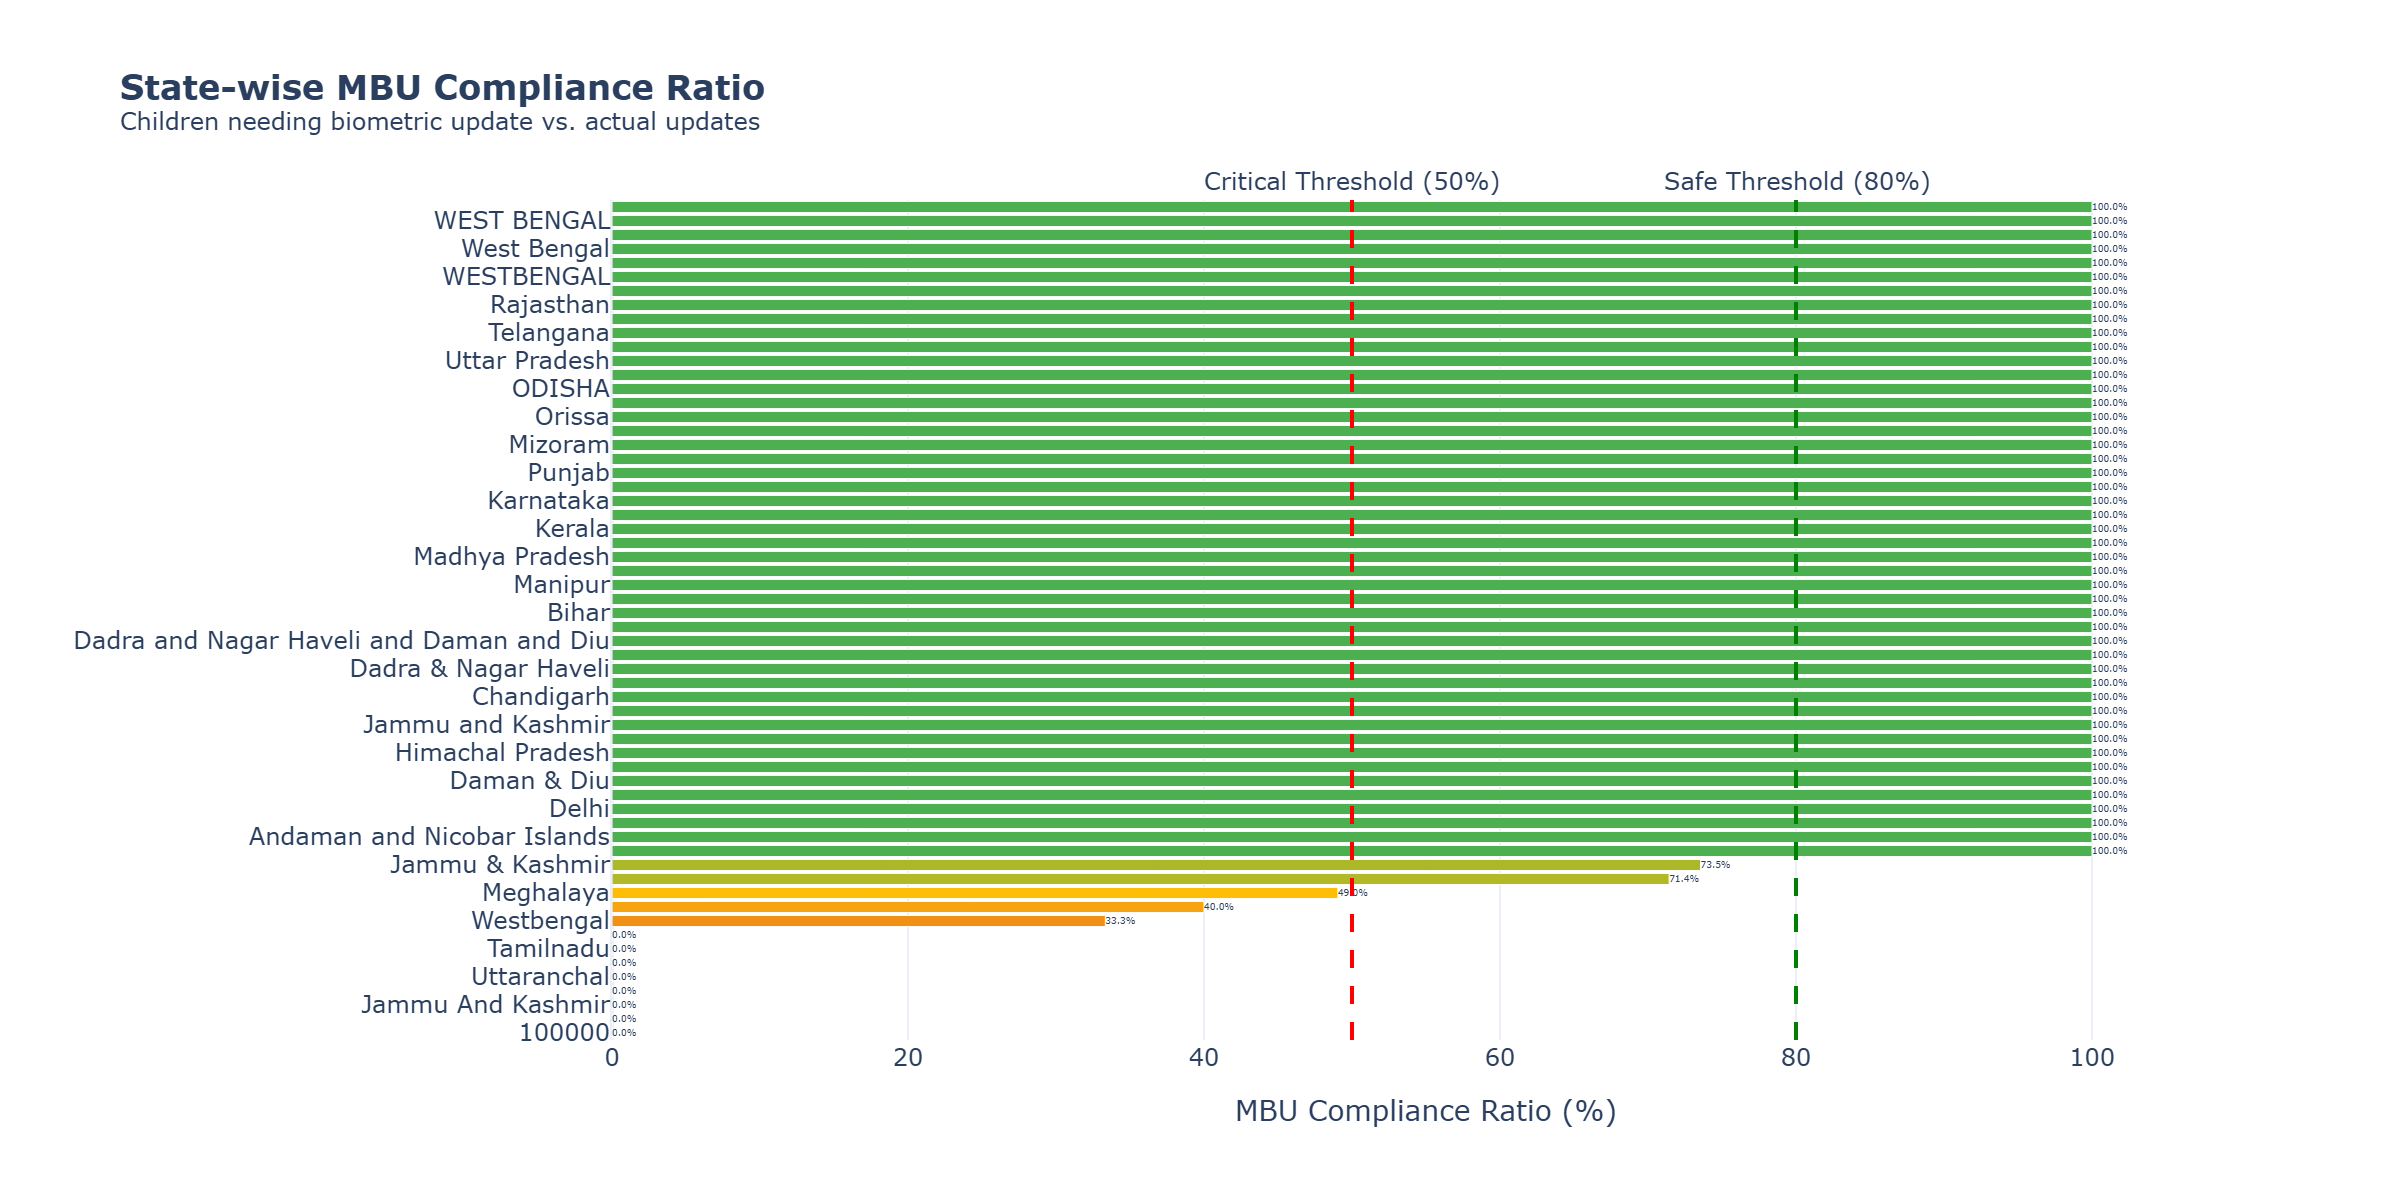

In [26]:
# State-level aggregation
state_summary = df_gap_analysis.groupby('state').agg({
    'mbu_eligible': 'sum',
    'bio_age_5_17': 'sum',
    'mbu_gap': 'sum',
    'district': 'count'
}).reset_index()

state_summary.columns = ['state', 'mbu_eligible', 'bio_updates', 'mbu_gap', 'district_count']

state_summary['compliance_ratio'] = np.where(
    state_summary['mbu_eligible'] > 0,
    (state_summary['bio_updates'] / state_summary['mbu_eligible']) * 100,
    0
).clip(0, 100)

state_summary = state_summary.sort_values('compliance_ratio')

# Create horizontal bar chart
fig1 = px.bar(
    state_summary,
    x='compliance_ratio',
    y='state',
    orientation='h',
    color='compliance_ratio',
    color_continuous_scale=['#d32f2f', '#ffc107', '#4caf50'],
    title='<b>State-wise MBU Compliance Ratio</b><br><sup>Children needing biometric update vs. actual updates</sup>',
    labels={'compliance_ratio': 'Compliance Ratio (%)', 'state': 'State'},
    text='compliance_ratio'
)

fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.update_layout(
    height=900,
    xaxis_title='MBU Compliance Ratio (%)',
    yaxis_title='',
    coloraxis_showscale=False,
    xaxis_range=[0, 110]
)

# Add threshold lines
fig1.add_vline(x=50, line_dash="dash", line_color="red", 
               annotation_text="Critical Threshold (50%)", annotation_position="top")
fig1.add_vline(x=80, line_dash="dash", line_color="green",
               annotation_text="Safe Threshold (80%)", annotation_position="top")

show_fig(fig1)

## Figure 2: MBU Gap Treemap (Children at Risk by State)

In [10]:
# Filter to show significant gaps
state_gap = state_summary[state_summary['mbu_gap'] > 0].copy()

fig2 = px.treemap(
    state_gap,
    path=['state'],
    values='mbu_gap',
    color='compliance_ratio',
    color_continuous_scale=['#d32f2f', '#ff9800', '#4caf50'],
    title='<b>MBU Gap Treemap: Children at Risk of Scholarship Denial</b><br><sup>Size = Gap count | Color = Compliance ratio</sup>',
    hover_data=['mbu_eligible', 'bio_updates', 'compliance_ratio']
)

fig2.update_layout(height=600)
fig2.update_traces(
    texttemplate="<b>%{label}</b><br>Gap: %{value:,.0f}<br>Compliance: %{color:.1f}%",
    textfont_size=12
)

show_fig(fig2)

## Layer 2: Service Desert Identification (K-Means Clustering)

In [11]:
# Prepare features for clustering
cluster_features = df_gap_analysis[[
    'state', 'district', 'mbu_eligible', 'bio_age_5_17', 
    'mbu_gap', 'mbu_compliance_ratio'
]].copy()

# Remove rows with zero eligible population
cluster_features = cluster_features[cluster_features['mbu_eligible'] > 0].copy()

# Prepare numerical features for clustering
X = cluster_features[['mbu_eligible', 'mbu_gap', 'mbu_compliance_ratio']].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"[INFO] Clustering {len(cluster_features)} districts based on MBU performance...")

[INFO] Clustering 1070 districts based on MBU performance...


In [12]:
# Find optimal number of clusters using Elbow Method
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig_elbow = make_subplots(rows=1, cols=2, subplot_titles=('Elbow Method', 'Silhouette Score'))

fig_elbow.add_trace(
    go.Scatter(x=list(K_range), y=inertias, mode='lines+markers', name='Inertia'),
    row=1, col=1
)

fig_elbow.add_trace(
    go.Scatter(x=list(K_range), y=silhouettes, mode='lines+markers', name='Silhouette'),
    row=1, col=2
)

fig_elbow.update_layout(
    title='<b>Optimal Cluster Selection</b>',
    height=400,
    showlegend=False
)

show_fig(fig_elbow)

# Use 4 clusters (typical: Service Desert, At Risk, Moderate, Compliant)
optimal_k = 4
print(f"\n[OK] Selected optimal clusters: {optimal_k}")


[OK] Selected optimal clusters: 4


In [13]:
# Apply K-Means with optimal clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_features['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster characteristics
cluster_summary = cluster_features.groupby('cluster').agg({
    'mbu_eligible': ['mean', 'sum'],
    'mbu_gap': ['mean', 'sum'],
    'mbu_compliance_ratio': 'mean',
    'district': 'count'
}).round(2)

cluster_summary.columns = ['Avg_Eligible', 'Total_Eligible', 'Avg_Gap', 'Total_Gap', 
                           'Avg_Compliance', 'District_Count']

# Name clusters based on characteristics
cluster_names = {
    cluster_summary['Avg_Compliance'].idxmin(): 'Service Desert',
    cluster_summary['Avg_Compliance'].idxmax(): 'High Performer'
}

# Assign intermediate clusters
remaining = [i for i in range(optimal_k) if i not in cluster_names]
sorted_remaining = sorted(remaining, key=lambda x: cluster_summary.loc[x, 'Avg_Compliance'])
if len(sorted_remaining) >= 2:
    cluster_names[sorted_remaining[0]] = 'At Risk'
    cluster_names[sorted_remaining[1]] = 'Moderate'
elif len(sorted_remaining) == 1:
    cluster_names[sorted_remaining[0]] = 'Moderate'

cluster_features['cluster_name'] = cluster_features['cluster'].map(cluster_names)

print("\nCLUSTER ANALYSIS RESULTS")
print("="*60)
for idx, row in cluster_summary.iterrows():
    print(f"\n{cluster_names.get(idx, f'Cluster {idx}')}:")
    print(f"   Districts: {int(row['District_Count'])}")
    print(f"   Avg Compliance: {row['Avg_Compliance']:.1f}%")
    print(f"   Total Gap: {int(row['Total_Gap']):,}")


CLUSTER ANALYSIS RESULTS

Moderate:
   Districts: 766
   Avg Compliance: 99.2%
   Total Gap: 3,555

High Performer:
   Districts: 178
   Avg Compliance: 99.8%
   Total Gap: 3,060

At Risk:
   Districts: 118
   Avg Compliance: 16.3%
   Total Gap: 70,876

Service Desert:
   Districts: 8
   Avg Compliance: 12.2%
   Total Gap: 100,409


## Figure 3: Service Desert Scatter Plot

In [14]:
fig3 = px.scatter(
    cluster_features,
    x='mbu_eligible',
    y='mbu_compliance_ratio',
    color='cluster_name',
    size='mbu_gap',
    hover_data=['state', 'district', 'mbu_gap'],
    title='<b>Service Desert Identification: District Clustering</b><br><sup>X = Eligible Population | Y = Compliance | Size = Gap</sup>',
    labels={
        'mbu_eligible': 'MBU Eligible Population',
        'mbu_compliance_ratio': 'Compliance Ratio (%)',
        'cluster_name': 'Category'
    },
    color_discrete_map={
        'Service Desert': '#d32f2f',
        'At Risk': '#ff9800',
        'Moderate': '#ffc107',
        'High Performer': '#4caf50'
    }
)

fig3.add_hline(y=50, line_dash="dash", line_color="red",
               annotation_text="Critical Threshold (50%)")
fig3.add_hline(y=80, line_dash="dash", line_color="green",
               annotation_text="Safe Threshold (80%)")

fig3.update_layout(height=600)
show_fig(fig3)

In [15]:
# List top Service Desert districts
service_deserts = cluster_features[
    cluster_features['cluster_name'] == 'Service Desert'
].nlargest(15, 'mbu_gap')[['state', 'district', 'mbu_eligible', 'mbu_gap', 'mbu_compliance_ratio']]

print("\nTOP 15 SERVICE DESERT DISTRICTS")
print("(Priority areas for Aadhaar Seva Kendra deployment)")
print("="*60)
display(service_deserts)


TOP 15 SERVICE DESERT DISTRICTS
(Priority areas for Aadhaar Seva Kendra deployment)


,state,district,mbu_eligible,mbu_gap,mbu_compliance_ratio
408,Karnataka,Bengaluru Urban,19278.0,19278.0,0.000000
146,Bihar,Pashchim Champaran,15797.0,15757.0,0.253213
149,Bihar,Purbi Champaran,14071.0,14071.0,0.000000
242,Gujarat,Banas Kantha,12716.0,12657.0,0.463982
1051,West Bengal,Dinajpur Uttar,11337.0,11337.0,0.000000
251,Gujarat,Dohad,12333.0,10165.0,17.578853
599,Meghalaya,East Khasi Hills,18864.0,9882.0,47.614504
610,Meghalaya,West Khasi Hills,10588.0,7262.0,31.412920


## Layer 3: Time Series Analysis and Forecasting

In [16]:
# Aggregate biometric updates by date
daily_updates = df_biometric.groupby('date').agg({
    'bio_age_5_17': 'sum',
    'bio_age_17_': 'sum'
}).reset_index()

daily_updates['total_updates'] = daily_updates['bio_age_5_17'] + daily_updates['bio_age_17_']
daily_updates = daily_updates.sort_values('date')

print(f"[INFO] Time Series Data Range: {daily_updates['date'].min()} to {daily_updates['date'].max()}")
print(f"[INFO] Total Days: {len(daily_updates)}")
print(f"[INFO] Average Daily Updates: {daily_updates['total_updates'].mean():,.0f}")

[INFO] Time Series Data Range: 2025-03-01 00:00:00 to 2025-12-29 00:00:00
[INFO] Total Days: 89
[INFO] Average Daily Updates: 783,855


## Figure 4: Daily MBU Update Trend

In [17]:
# Create time series visualization
fig4 = go.Figure()

# Add total updates line
fig4.add_trace(go.Scatter(
    x=daily_updates['date'],
    y=daily_updates['total_updates'],
    mode='lines',
    name='Total Biometric Updates',
    line=dict(color='#1976d2', width=2),
    fill='tozeroy',
    fillcolor='rgba(25, 118, 210, 0.3)'
))

# Add 7-day moving average
daily_updates['ma_7'] = daily_updates['total_updates'].rolling(window=7).mean()
fig4.add_trace(go.Scatter(
    x=daily_updates['date'],
    y=daily_updates['ma_7'],
    mode='lines',
    name='7-Day Moving Average',
    line=dict(color='#d32f2f', width=3, dash='dash')
))

fig4.update_layout(
    title='<b>Daily Biometric Update Trends</b><br><sup>Tracking MBU compliance over time</sup>',
    xaxis_title='Date',
    yaxis_title='Number of Updates',
    height=500,
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

show_fig(fig4)

In [18]:
# Prophet Forecasting (if available)
if PROPHET_AVAILABLE:
    print("[INFO] Running Prophet Time Series Forecast...\n")
    
    # Prepare data for Prophet
    prophet_df = daily_updates[['date', 'total_updates']].copy()
    prophet_df.columns = ['ds', 'y']
    prophet_df = prophet_df.dropna()
    
    # Initialize and fit model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    
    # Forecast 6 months ahead (June-July 2026 school admission season)
    future = model.make_future_dataframe(periods=180)
    forecast = model.predict(future)
    
    print("[OK] Forecast complete!")
    print(f"[INFO] Forecast range: {forecast['ds'].min()} to {forecast['ds'].max()}")
else:
    print("[INFO] Prophet not available. Using simple trend projection instead.")
    
    # Simple linear trend projection
    from sklearn.linear_model import LinearRegression
    
    prophet_df = daily_updates[['date', 'total_updates']].copy().dropna()
    prophet_df['days'] = (prophet_df['date'] - prophet_df['date'].min()).dt.days
    
    lr = LinearRegression()
    lr.fit(prophet_df[['days']], prophet_df['total_updates'])
    
    # Create future dates
    last_date = prophet_df['date'].max()
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=180)
    future_days = [(d - prophet_df['date'].min()).days for d in future_dates]
    
    forecast = pd.DataFrame({
        'ds': list(prophet_df['date']) + list(future_dates),
        'yhat': list(prophet_df['total_updates']) + list(lr.predict(np.array(future_days).reshape(-1, 1)))
    })
    forecast['yhat_lower'] = forecast['yhat'] * 0.85
    forecast['yhat_upper'] = forecast['yhat'] * 1.15

[INFO] Prophet not available. Using simple trend projection instead.


## Figure 5: Forecast - The Update Crunch Prediction

In [19]:
fig5 = go.Figure()

# Historical data
fig5.add_trace(go.Scatter(
    x=daily_updates['date'],
    y=daily_updates['total_updates'],
    mode='lines',
    name='Historical Updates',
    line=dict(color='#1976d2', width=2)
))

# Forecast
future_mask = forecast['ds'] > daily_updates['date'].max()
fig5.add_trace(go.Scatter(
    x=forecast[future_mask]['ds'],
    y=forecast[future_mask]['yhat'],
    mode='lines',
    name='Forecasted Updates',
    line=dict(color='#4caf50', width=2, dash='dash')
))

# Confidence interval
if 'yhat_lower' in forecast.columns:
    fig5.add_trace(go.Scatter(
        x=list(forecast[future_mask]['ds']) + list(forecast[future_mask]['ds'][::-1]),
        y=list(forecast[future_mask]['yhat_upper']) + list(forecast[future_mask]['yhat_lower'][::-1]),
        fill='toself',
        fillcolor='rgba(76, 175, 80, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Confidence Interval'
    ))

# Mark school admission season (June-July)
fig5.add_vrect(
    x0="2026-06-01", x1="2026-07-31",
    fillcolor="rgba(255, 152, 0, 0.3)",
    layer="below",
    line_width=0,
    annotation_text="School Admission Season",
    annotation_position="top left"
)

fig5.update_layout(
    title='<b>MBU Update Forecast: Predicting the Update Crunch</b><br><sup>6-month forecast for school admission preparedness</sup>',
    xaxis_title='Date',
    yaxis_title='Daily Biometric Updates',
    height=500,
    hovermode='x unified'
)

show_fig(fig5)

## Impact Quantification: Scholarship Risk Calculator

In [20]:
# Calculate total children at risk
total_mbu_gap = df_gap_analysis['mbu_gap'].sum()

# Scholarship values (Government of India estimates)
AVG_SCHOLARSHIP_VALUE = 12000  # Rs. 12,000 average annual scholarship
DBT_BENEFIT_PER_CHILD = 6000   # Rs. 6,000 DBT benefits (Mid-day meal, etc.)

# Calculate financial impact
scholarship_at_risk = total_mbu_gap * AVG_SCHOLARSHIP_VALUE
dbt_at_risk = total_mbu_gap * DBT_BENEFIT_PER_CHILD
total_financial_impact = scholarship_at_risk + dbt_at_risk

print("\nIMPACT QUANTIFICATION: SCHOLARSHIP RISK")
print("="*60)
print(f"\n[ALERT] Total Children with MBU Gap: {total_mbu_gap:,.0f}")
print(f"\nFinancial Impact if Unaddressed:")
print(f"   - Scholarships at Risk: Rs. {scholarship_at_risk/1e7:,.2f} Crore")
print(f"   - DBT Benefits at Risk: Rs. {dbt_at_risk/1e7:,.2f} Crore")
print(f"   " + "-"*45)
print(f"   TOTAL IMPACT: Rs. {total_financial_impact/1e7:,.2f} Crore")


IMPACT QUANTIFICATION: SCHOLARSHIP RISK

[ALERT] Total Children with MBU Gap: 177,900

Financial Impact if Unaddressed:
   - Scholarships at Risk: Rs. 213.48 Crore
   - DBT Benefits at Risk: Rs. 106.74 Crore
   ---------------------------------------------
   TOTAL IMPACT: Rs. 320.22 Crore


In [21]:
# Impact visualization
impact_data = pd.DataFrame({
    'Category': ['Scholarships at Risk', 'DBT Benefits at Risk'],
    'Amount_Crore': [scholarship_at_risk/1e7, dbt_at_risk/1e7],
    'Children_Affected': [total_mbu_gap, total_mbu_gap]
})

fig_impact = px.bar(
    impact_data,
    x='Category',
    y='Amount_Crore',
    color='Category',
    title='<b>Financial Impact of MBU Non-Compliance</b><br><sup>Government benefits at risk due to inactive Aadhaar</sup>',
    labels={'Amount_Crore': 'Amount (Rs. Crore)'},
    text='Amount_Crore',
    color_discrete_sequence=['#d32f2f', '#ff9800']
)

fig_impact.update_traces(texttemplate='Rs. %{text:.2f} Cr', textposition='outside')
fig_impact.update_layout(height=400, showlegend=False)
show_fig(fig_impact)

---

## Executive Summary and Policy Recommendations

In [22]:
# Calculate key metrics for summary
total_districts = len(df_gap_analysis)
service_desert_count = len(df_gap_analysis[df_gap_analysis['risk_category'] == 'Red (Service Desert)'])
moderate_risk_count = len(df_gap_analysis[df_gap_analysis['risk_category'] == 'Yellow (Moderate Risk)'])
compliant_count = len(df_gap_analysis[df_gap_analysis['risk_category'] == 'Green (Compliant)'])

avg_compliance = df_gap_analysis['mbu_compliance_ratio'].mean()

# Get top 5 critical states
top_critical_states = state_summary.nsmallest(5, 'compliance_ratio')['state'].tolist()

print("\n" + "="*70)
print("EXECUTIVE SUMMARY: MBU GAP ANALYZER")
print("="*70)

print(f"""
+---------------------------------------------------------------------+
|                        KEY FINDINGS                                 |
+---------------------------------------------------------------------+
| Total Districts Analyzed:        {total_districts:>6,}                          |
| Service Desert Districts:        {service_desert_count:>6,}  ({service_desert_count/total_districts*100:.1f}%)                   |
| Moderate Risk Districts:         {moderate_risk_count:>6,}  ({moderate_risk_count/total_districts*100:.1f}%)                   |
| Compliant Districts:             {compliant_count:>6,}  ({compliant_count/total_districts*100:.1f}%)                   |
|                                                                     |
| Average MBU Compliance:          {avg_compliance:>6.1f}%                          |
| Children at Risk (Gap):      {total_mbu_gap:>10,.0f}                          |
| Financial Impact:            Rs.{total_financial_impact/1e7:>8,.2f} Crore                   |
+---------------------------------------------------------------------+

TOP 5 CRITICAL STATES (Lowest Compliance):
   {', '.join(top_critical_states)}
""")

print("""
+---------------------------------------------------------------------+
|                    POLICY RECOMMENDATIONS                           |
+---------------------------------------------------------------------+
| 1. DEPLOY MOBILE AADHAAR SEVA KENDRAS in Service Desert districts,  |
|    especially in rural and tribal areas.                            |
|                                                                     |
| 2. LAUNCH SMS/IVR REMINDER CAMPAIGNS targeting parents of children  |
|    turning 5 and 15 in the next 6 months.                           |
|                                                                     |
| 3. INTEGRATE MBU STATUS CHECK with school admission portals to flag |
|    children with inactive Aadhaar proactively.                      |
|                                                                     |
| 4. EXTEND FEE WAIVER beyond Oct 2025 for states with compliance     |
|    ratio below 50%.                                                 |
|                                                                     |
| 5. DASHBOARD DEPLOYMENT: Real-time MBU tracking dashboard for       |
|    District Collectors to monitor weekly progress.                  |
+---------------------------------------------------------------------+
""")


EXECUTIVE SUMMARY: MBU GAP ANALYZER

+---------------------------------------------------------------------+
|                        KEY FINDINGS                                 |
+---------------------------------------------------------------------+
| Total Districts Analyzed:         1,109                          |
| Service Desert Districts:           147  (13.3%)                   |
| Moderate Risk Districts:             32  (2.9%)                   |
| Compliant Districts:                930  (83.9%)                   |
|                                                                     |
| Average MBU Compliance:            86.4%                          |
| Children at Risk (Gap):         177,900                          |
| Financial Impact:            Rs.  320.22 Crore                   |
+---------------------------------------------------------------------+

TOP 5 CRITICAL STATES (Lowest Compliance):
   100000, Chhatisgarh, Jammu And Kashmir, odisha, Uttaranchal


+---

---

## Export Results for PDF Report

In [23]:
# Export key dataframes for the report
output_dir = 'analysis_outputs'
os.makedirs(output_dir, exist_ok=True)

# Export gap analysis
df_gap_analysis.to_csv(f'{output_dir}/mbu_gap_analysis_by_district.csv', index=False)

# Export state summary
state_summary.to_csv(f'{output_dir}/state_wise_compliance_summary.csv', index=False)

# Export service desert districts
cluster_features[cluster_features['cluster_name'] == 'Service Desert'].to_csv(
    f'{output_dir}/service_desert_districts.csv', index=False
)

# Export ghost cohorts
ghost_cohorts.to_csv(f'{output_dir}/ghost_cohort_districts.csv', index=False)

print("\n[OK] All analysis outputs exported to 'analysis_outputs/' folder")
print("\nFiles created:")
for f in os.listdir(output_dir):
    print(f"   - {f}")


[OK] All analysis outputs exported to 'analysis_outputs/' folder

Files created:
   - ghost_cohort_districts.csv
   - mbu_gap_analysis_by_district.csv
   - service_desert_districts.csv
   - state_wise_compliance_summary.csv


In [24]:
# Save all figures as HTML (can be converted to PDF)
fig1.write_html(f'{output_dir}/chart1_state_compliance.html')
fig2.write_html(f'{output_dir}/chart2_gap_treemap.html')
fig3.write_html(f'{output_dir}/chart3_service_desert_scatter.html')
fig4.write_html(f'{output_dir}/chart4_daily_trends.html')
fig5.write_html(f'{output_dir}/chart5_forecast.html')
fig_impact.write_html(f'{output_dir}/chart6_financial_impact.html')

print("\n[OK] All visualizations saved as interactive HTML files")
print("   Tip: Open in browser and use Print > Save as PDF")


[OK] All visualizations saved as interactive HTML files
   Tip: Open in browser and use Print > Save as PDF


---

## Submission Checklist

| # | Component | Status |
|---|-----------|--------|
| 1 | Problem Statement (MBU Gap) | Complete |
| 2 | Data Loading and Preprocessing | Complete |
| 3 | Cohort Tracking Logic | Complete |
| 4 | MBU Compliance Ratio Formula | Complete |
| 5 | Ghost Cohort Identification | Complete |
| 6 | K-Means Service Desert Clustering | Complete |
| 7 | Time Series Forecasting | Complete |
| 8 | Financial Impact Quantification | Complete |
| 9 | 5 Key Visualizations | Complete |
| 10 | Policy Recommendations | Complete |

---

**Submitted by:** Team OMEGA  
**Hackathon:** UIDAI Data Hackathon 2026

---